In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

## Get Equally Spaced Freqs

In [2]:
freqs = np.logspace(-2, 2, 41)

## Sample freqs equally spaced in logspace 

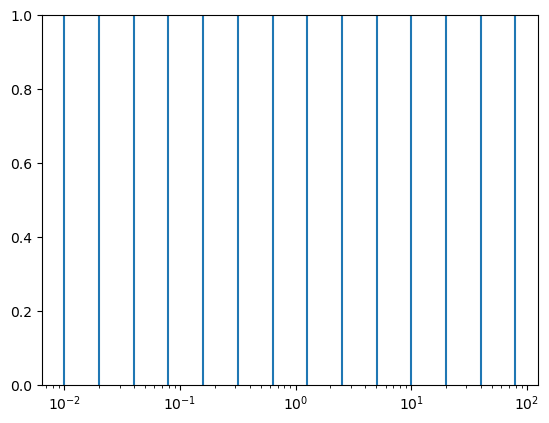

In [3]:
freqs_sampled = freqs[0::3]

fig = plt.figure()

for f in freqs_sampled:
    plt.axvline(f)

plt.xscale('log')
plt.show()

## Calculate Skin Depths for Half Space

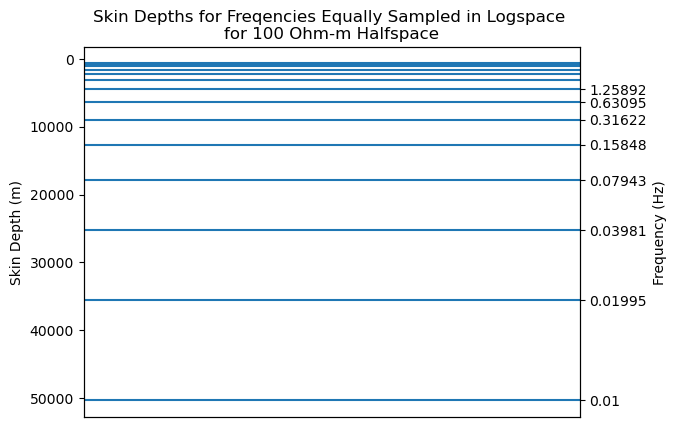

In [37]:
rho = 100

delta = 503 * np.sqrt(rho / freqs_sampled)

fig, ax = plt.subplots()

for d in delta:
    plt.axhline(d)

plt.gca().invert_yaxis()


freqs_sampled_trunc =  np.trunc(freqs_sampled * 10**5) / (10**5)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(delta[:8], labels=freqs_sampled_trunc[:8])

ax.set_ylabel('Skin Depth (m)')
ax2.set_ylabel('Frequency (Hz)')
ax.xaxis.set_visible(False)

plt.title(f'Skin Depths for Freqencies Equally Sampled in Logspace \nfor {rho} Ohm-m Halfspace')

plt.show()

## Calculate Skin Depth Distortion from Anomaly

In [9]:
def skin_depth_layered(z1, z2, rho1, rho2, rho3, freq):
    delta1 = 503 * np.sqrt(rho1 / freq)
    delta2 = 503 * np.sqrt(rho2 / freq)
    delta3 = 503 * np.sqrt(rho3 / freq)

    if z1 > delta1:
        return delta1
    elif z2 > delta2 * (1 - z1 / delta1):
        return z1 + delta2 * (1 - (z1 / delta1))
    else:
        return z1 + z2 + delta3 * (1 - (z1 / delta1) - (z2 / delta2))


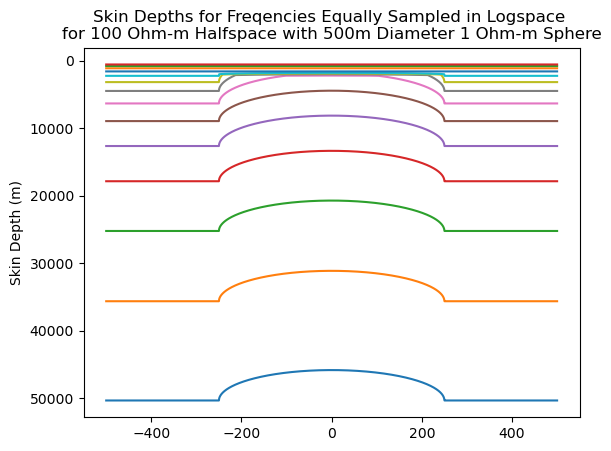

In [39]:
pts = np.linspace(-500, 500, 10000)

# sphere anomaly dims
r = 250
d = 2000
rho_back = 100
rho_sphere = 1

freq_deltas = []
for f in freqs_sampled:
    delta = []
    for x in pts:
        if np.abs(x) > r:
            delta.append(503 * np.sqrt(rho_back / f))
        else:
            z1 = d - np.sqrt(r**2 - x**2)
            z2 = d + np.sqrt(r**2 - x**2) - z1
            delta.append(skin_depth_layered(z1, z2, rho_back, rho_sphere, rho_back, f))
    freq_deltas.append(delta)

for delta in freq_deltas:
    plt.plot(pts, delta)
plt.gca().invert_yaxis()

plt.ylabel('Skin Depth (m)')

plt.title(f'Skin Depths for Freqencies Equally Sampled in Logspace \nfor {rho_back} Ohm-m Halfspace with 500m Diameter {rho_sphere} Ohm-m Sphere')

plt.show()